<a href="https://colab.research.google.com/github/LorenzoBioinfo/import-biology/blob/main/notebooks/BLAST_with_Biopython.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Allineamento con BLAST via API

## Background per il notebook

Cos'è  **BLAST**?
BLAST (Basic Local Alignment Search Tool) è uno dei tool più usati in bioinformatica. Data una sequenza (detta *query*), BLAST cerca in un database che può contenere milioni di sequenze e restituisce quelle più simili, in ordine di somiglianza.

La parola chiave è **local**. BLAST cerca i migliori allineamenti locali tra sequenze, non necessariamente end-to-end (globali).
L'approccio locale rende BLAST molto più rapido e adatto a trovare domini conservati, identificare omologhi tra specie ecc.

Come funziona BLAST?

Allineare la sequenza query con ogni singola sequenza del database sarebbe impensabile.
BLAST utilizza un altro approccio:

- Step 1 — Word finding: BLAST spezzetta la sequenza query in piccole sottosequenze (*words*) overlappanti (default: 11 bp per DNA, 3 aa per proteins) and trova tutti i match esatti di queste sottosequenze nel database. Questi match sono chiamati *seeds*.
Step 2 — Extension: Ogni seed è poi "esteso" in entrambe le direzioni se lo score dell'allineamento aumenta. Questo produce un allineamento locale chiamato HSP (High-scoring Segment Pair).
Step 3 — Scoring and filtering: Ogni HSP riceve uno score sulla base di  matches, mismatches e gaps. Solo HSPs sopra una certa soglia sono riportati nei risultati.

L'output che restituisce BLAST è una lista di HITS, cioè le sequenze del database con almeno una HSP significativa contro la sequenza query.

** The E-value** : il valore più importante

Per ogni hit, BLAST fornisce anche un E-value (Expect value). Questo numero corrisponde al numero di hits che ti saresti aspettato di trovare per puro caso in un database della stessa size e con lo stesso score.

Come interpretarlo?
E-value
- < 1e-50 Very strong match.  Quasi sicuramente sequenza omologa
- 1e-50 → 1e-10 Strong match, probabilmente omologa
- 1e-10 → 0.01  Moderate , da investigare
- 0.01- >0.01 Weak, rumore di fondo



In questo notebook useremo BLASTn per cercare omologhi di una sequenza nucleotica(16S rRNA gene di E. coli) nel database NCBI nt.

Poi proveremo a ripetere lo stesso flow sul gene BRCA1 umano.

## 0 - Setup

In [24]:
import sys
IN_COLAB="google.colab" in sys.modules
if IN_COLAB:
  !pip install biopython --quiet

## 1 - Download Sequenza

Per scaricare la sequenza, la prima cosa che dobbiamo fare è ottenere l'accession ID da NCBI.

Per il gene 16S rRNA di E.coli il codice è

In [25]:
from Bio import SeqIO, Entrez
import os
from pathlib import Path


Entrez.email ="inserisciemail@email.com"

ACCESSIONID="J01695.2"
FASTA_PATH=Path("J01695.2.fasta")


if not FASTA_PATH.exists():
  print(f"Scaricando {ACCESSIONID} da NCBI")
  handle=Entrez.efetch(
      db="nucleotide", # Vogliamo la sequenza nucleotidica
      id=ACCESSIONID, #
      rettype="fasta", # Questo parametro specifica il formato di dati che vogliamo
      retmode="text" # Questo in che formato (text, xml, json)
  )

  with open(FASTA_PATH, "w") as f:
    f.write(handle.read())
    print("Terminato!")
else:
    print("Genoma già scaricato")

Genoma già scaricato


## 2 - Esaminiamo la sequenza

In [26]:
record=SeqIO.read(FASTA_PATH, "fasta")
print(f"ID: {record.id}")
print(f"Description: {record.description}")
print(f"First 10 nt: {record.seq[:10]}")
print(f"Total length: {len(record.description)} bp")

ID: J01695.2
Description: J01695.2 E.coli rRNA operon (rrnB) coding for Glu-tRNA-2, 5S, 16S and 23S rRNA
First 10 nt: TAGCCAACCT
Total length: 78 bp


In [27]:
## 3 - QUERY BLAST

Questo step è un po' lento, potrebbero volerci 30-60 secondi perché NCBI mette in coda le richieste. Alla fine avremo un file XML con i risultati

In [28]:
from Bio.Blast import NCBIWWW, NCBIXML
import time

BLAST_XML = Path("blast_16S_results.xml")

if not BLAST_XML.exists():
    print("Submitting BLAST query to NCBI... ")

    result_handle = NCBIWWW.qblast(
        program="blastn",       # DNA vs DNA
        database="nt",          # NCBI nucleotide database di tutti i genomi
        sequence=record.seq,    # la nostra sequenza 16S di E. coli
        hitlist_size=50,        # massimo 50 hit
        expect=0.001            # soglia E-value. Scartiamo hit troppo deboli
    )

    with open(BLAST_XML, "w") as f:
        f.write(result_handle.read())

    print(f"Done! Results saved to {BLAST_XML}")
else:
    print(f"{BLAST_XML} already exists, loading from disk.")

blast_16S_results.xml already exists, loading from disk.


In [29]:
#Esploriamo  i risultati

with open(BLAST_XML, "r") as f:
    blast_record = NCBIXML.read(f)


print(f"Query: {blast_record.query_id}")
print(f"Database: {blast_record.database}")
print(f"Hit totali: {len(blast_record.alignments)}")


Query: Query_1071247
Database: core_nt
Hit totali: 50


In [30]:
import pandas as pd

rows = []

for alignment in blast_record.alignments:
    for hsp in alignment.hsps:


        query_coverage = round(hsp.align_length / blast_record.query_length * 100, 1)

        identity_pct = round(hsp.identities / hsp.align_length * 100, 1)

        rows.append({
            "hit_id"      : alignment.hit_id,
            "description" : alignment.hit_def[:60],
            "length_bp"   : alignment.length,
            "score"       : hsp.score,
            "e_value"     : hsp.expect,
            "identity_pct": identity_pct,
            "coverage_pct": query_coverage,
            "gaps"        : hsp.gaps,
        })

df = pd.DataFrame(rows)

df = df.sort_values("e_value").reset_index(drop=True)

print(f"Hit totali nel DataFrame: {len(df)}")

print(df[["description", "e_value", "identity_pct", "coverage_pct"]].head(10).to_string(index=False))

Hit totali nel DataFrame: 735
                                                 description  e_value  identity_pct  coverage_pct
Escherichia coli BW25113 substr. CHXR2G20 chromosome, comple      0.0          99.3          47.6
Escherichia coli BW25113 substr. CHXR2G20 chromosome, comple      0.0          99.6          46.7
Escherichia coli strain S-P-C-029.01 chromosome, complete ge      0.0          99.3          47.6
Escherichia coli strain S-P-C-029.01 chromosome, complete ge      0.0          99.6          46.7
Escherichia coli strain S-P-C-029.01 chromosome, complete ge      0.0          99.2          46.7
Escherichia coli strain S-P-C-029.01 chromosome, complete ge      0.0          99.2          44.8
Escherichia coli strain S-P-C-029.01 chromosome, complete ge      0.0          99.2          44.7
Escherichia coli strain S-P-C-029.01 chromosome, complete ge      0.0          99.7          26.9
Escherichia coli strain S-P-C-029.01 chromosome, complete ge      0.0          99.4     

 ## Visualizziamo



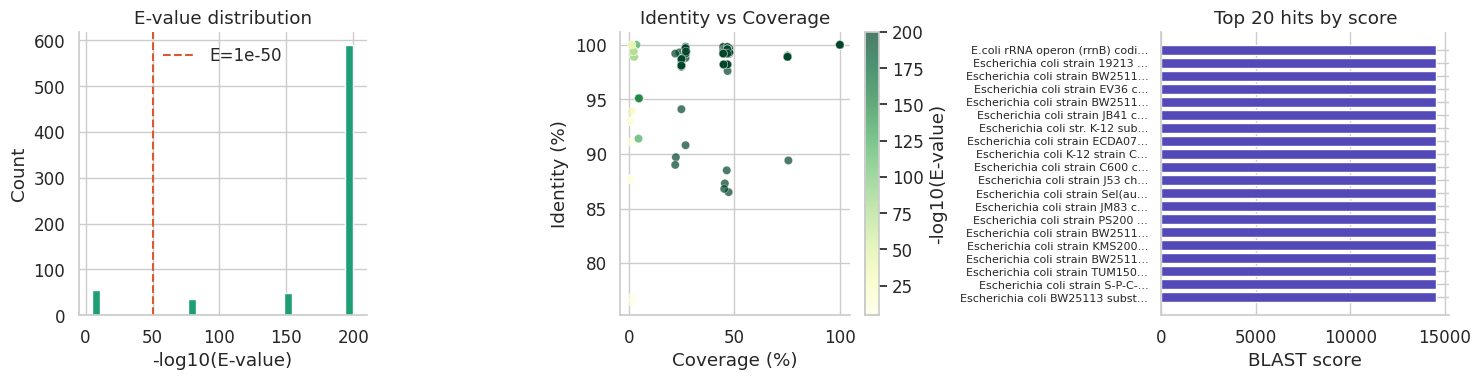

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


sns.set_theme(style="whitegrid", font_scale=1.1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))


# 1  Distribuzione E-value (scala logaritmica)
log_evalues = [-np.log10(e) if e > 0 else 200 for e in df["e_value"]]
axes[0].hist(log_evalues, bins=30, color="#1D9E75", edgecolor="white")
axes[0].set_xlabel("-log10(E-value)")
axes[0].set_ylabel("Count")
axes[0].set_title("E-value distribution")
axes[0].axvline(50, color="#D85A30", linestyle="--", linewidth=1.5, label="E=1e-50")
axes[0].legend(frameon=False)


# 2 Identity vs Coverage Scatter plot

scatter = axes[1].scatter(
    df["coverage_pct"],
    df["identity_pct"],
    c=log_evalues,
    cmap="YlGn",
    alpha=0.7,
    edgecolors="white",
    linewidth=0.3
)
plt.colorbar(scatter, ax=axes[1], label="-log10(E-value)")
axes[1].set_xlabel("Coverage (%)")
axes[1].set_ylabel("Identity (%)")
axes[1].set_title("Identity vs Coverage")


# 3 Top 20 hit — score bar chart
top20 = df.nlargest(20, "score").sort_values("score")
short_desc = top20["description"].str[:30] + "..."
axes[2].barh(range(len(top20)), top20["score"], color="#534AB7", edgecolor="white")
axes[2].set_yticks(range(len(top20)))
axes[2].set_yticklabels(short_desc, fontsize=8)
axes[2].set_xlabel("BLAST score")
axes[2].set_title("Top 20 hits by score")

sns.despine()
plt.tight_layout()
plt.savefig("blast_plots.png", dpi=150, bbox_inches="tight")
plt.show()

## BRCA1
Ripetiamo tutti i passaggi per il gene BRCA1. Questa volta non utilizzeremo la sequenze nucleotidica ma peptidica.

Iniziamo scaricando la sequenza nucleotidica con Accesssion ID NM_007294.4. Poi
otterremo la sequenza proteica con .translate() per poi passarla a BLASTP.


In [36]:
Entrez.email ="inserisciemail@email.com"

ACCESSIONID="NM_007294.4"
FASTA_PATH=Path("NM_007294.4.fasta")


if not FASTA_PATH.exists():
  print(f"Scaricando {ACCESSIONID} da NCBI")
  handle=Entrez.efetch(
      db="nucleotide", # Vogliamo la sequenza peptidica
      id=ACCESSIONID, #
      rettype="fasta", # Questo parametro specifica il formato di dati che vogliamo
      retmode="text" # Questo in che formato (text, xml, json)
  )

  with open(FASTA_PATH, "w") as f:
    f.write(handle.read())
    print("Terminato!")
else:
    print("Proteina già scaricata")

Scaricando NM_007294.4 da NCBI
Terminato!


In [44]:
report=SeqIO.read("NM_007294.4.fasta", "fasta")


print(f"ID: {report.id}")
print(f"Description: {report.description}")
print(f"First 60 bp: {report.seq[:60]}")
print(f"Total length: {len(report.seq)} aa")

ID: NM_007294.4
Description: NM_007294.4 Homo sapiens BRCA1 DNA repair associated (BRCA1), transcript variant 1, mRNA
First 60 bp: GCTGAGACTTCCTGGACGGGGGACAGGCTGTGGGGTTTCTCAGATAACTGGGCCCCTGCG
Total length: 7088 aa


Ora otteniamo la sequenza proteica utilizzando il metodo .translate()

In [51]:
seq_prot=report.seq.translate(to_stop=True,table="Standard",)
print(seq_prot)

AETSWTGDRLWGFSDNWAPALRRPSPSALGKVHWNRKKWIYLLFALKKYKMSLMLCRKS


/usr/local/lib/python3.12/dist-packages/Bio/Seq.py:2874: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


Qualcosa non va! Il problema è che la sequenza FASTA contiene anche la regione UTR e non è facilmente intuibile con traslate quale è il reading frame corretto.

La cosa migliore da fare è scaricare da GenBank le coordinate esatte della regione codificante.
Vediamo come.

In [54]:
ACCESSIONID="NM_007294.4"
GB_PATH=Path("NM_007294.4.gb")


if not GB_PATH.exists():
  print(f"Scaricando {ACCESSIONID} da NCBI")
  handle=Entrez.efetch(
      db="nucleotide",
      id=ACCESSIONID, #
      rettype="gb", # Formato di GB
      retmode="text" # Questo in che formato (text, xml, json)
  )

  with open(GB_PATH, "w") as f:
    f.write(handle.read())
    print("Terminato!")
else:
    print("Proteina già scaricata")

Scaricando NM_007294.4 da NCBI
Terminato!


In [56]:
cds_record=SeqIO.read(GB_PATH, "genbank")
print(f"ID: {cds_record.id}")
print(f"Description: {cds_record.description}")
print(f"Total length: {len(cds_record.seq)} aa")



ID: NM_007294.4
Description: Homo sapiens BRCA1 DNA repair associated (BRCA1), transcript variant 1, mRNA
Total length: 7088 aa


E' molto simile al record che abbiamo scaricato prima ma contiene delle informazioni in più.

In [59]:
for key, value in cds_record.annotations.items():
  print(f"{key}: {value}")

molecule_type: mRNA
topology: linear
data_file_division: PRI
date: 22-JAN-2026
accessions: ['NM_007294']
sequence_version: 4
keywords: ['RefSeq', 'MANE Select']
source: Homo sapiens (human)
organism: Homo sapiens
taxonomy: ['Eukaryota', 'Metazoa', 'Chordata', 'Craniata', 'Vertebrata', 'Euteleostomi', 'Mammalia', 'Eutheria', 'Euarchontoglires', 'Primates', 'Haplorrhini', 'Catarrhini', 'Hominidae', 'Homo']
references: [Reference(title='Emerging roles of BRCA1 alternative splicing', ...), Reference(title='Expression profiles of BRCA1 splice variants in asynchronous and in G1/S synchronized tumor cell lines', ...), Reference(title='BRCA1: a review of structure and putative functions', ...), Reference(title='Mutations and alternative splicing of the BRCA1 gene in UK breast/ovarian cancer families', ...), Reference(title='Differential subcellular localization, expression and biological toxicity of BRCA1 and the splice variant BRCA1-delta11b', ...), Reference(title='Localization of BRCA1 and 

Quello a cui siamo interessati è l'annotazione CDS.

In [60]:
cds_record.features


[SeqFeature(SimpleLocation(ExactPosition(0), ExactPosition(7088), strand=1), type='source', qualifiers=...),
 SeqFeature(SimpleLocation(ExactPosition(0), ExactPosition(7088), strand=1), type='gene', qualifiers=...),
 SeqFeature(SimpleLocation(ExactPosition(0), ExactPosition(94), strand=1), type='exon', qualifiers=...),
 SeqFeature(SimpleLocation(ExactPosition(89), ExactPosition(92), strand=1), type='misc_feature', qualifiers=...),
 SeqFeature(SimpleLocation(ExactPosition(94), ExactPosition(193), strand=1), type='exon', qualifiers=...),
 SeqFeature(SimpleLocation(ExactPosition(113), ExactPosition(5705), strand=1), type='CDS', qualifiers=...),
 SeqFeature(SimpleLocation(ExactPosition(113), ExactPosition(116), strand=1), type='misc_feature', qualifiers=...),
 SeqFeature(SimpleLocation(ExactPosition(452), ExactPosition(455), strand=1), type='misc_feature', qualifiers=...),
 SeqFeature(SimpleLocation(ExactPosition(800), ExactPosition(923), strand=1), type='misc_feature', qualifiers=...),
 S

In [62]:
CDS_info=[feature for feature in cds_record.features if feature.type=="CDS"][0]
CDS_info

SeqFeature(SimpleLocation(ExactPosition(113), ExactPosition(5705), strand=1), type='CDS', qualifiers=...)

Bingo! Da qui abbiamo la posizione di inizio e stop della regione codificante.
Estraiamola dalla sequenza è applichiamo il metodo translate().

In [76]:
start=CDS_info.location.start
end=CDS_info.location.end

print(f"Start : {start}")
print(f"Stop : {end}")
print(f"Len : {end-start}")


brca_full=cds_record.seq
brca_cds=brca_full[start:end]
print(brca_cds[:3])
brca_prot=brca_cds.translate(to_stop=True,table="Standard")

print(brca_prot)
print(f"Protein length : {len(brca_prot)}")


Start : 113
Stop : 5705
Len : 5592
ATG
MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKFCMLKLLNQKKGPSQCPLCKNDITKRSLQESTRFSQLVEELLKIICAFQLDTGLEYANSYNFAKKENNSPEHLKDEVSIIQSMGYRNRAKRLLQSEPENPSLQETSLSVQLSNLGTVRTLRTKQRIQPQKTSVYIELGSDSSEDTVNKATYCSVGDQELLQITPQGTRDEISLDSAKKAACEFSETDVTNTEHHQPSNNDLNTTEKRAAERHPEKYQGSSVSNLHVEPCGTNTHASSLQHENSSLLLTKDRMNVEKAEFCNKSKQPGLARSQHNRWAGSKETCNDRRTPSTEKKVDLNADPLCERKEWNKQKLPCSENPRDTEDVPWITLNSSIQKVNEWFSRSDELLGSDDSHDGESESNAKVADVLDVLNEVDEYSGSSEKIDLLASDPHEALICKSERVHSKSVESNIEDKIFGKTYRKKASLPNLSHVTENLIIGAFVTEPQIIQERPLTNKLKRKRRPTSGLHPEDFIKKADLAVQKTPEMINQGTNQTEQNGQVMNITNSGHENKTKGDSIQNEKNPNPIESLEKESAFKTKAEPISSSISNMELELNIHNSKAPKKNRLRRKSSTRHIHALELVVSRNLSPPNCTELQIDSCSSSEEIKKKKYNQMPVRHSRNLQLMEGKEPATGAKKSNKPNEQTSKRHDSDTFPELKLTNAPGSFTKCSNTSELKEFVNPSLPREEKEEKLETVKVSNNAEDPKDLMLSGERVLQTERSVESSSISLVPGTDYGTQESISLLEVSTLGKAKTEPNKCVSQCAAFENPKGLIHGCSKDNRNDTEGFKYPLGHEVNHSRETSIEMEESELDAQYLQNTFKVSKRQSFAPFSNPGNAEEECATFSAHSGSLKKQSPKVTFECEQKEENQGKNESNIKPVQTVNITAGFPVVGQKDKPVDNAKCSIKGGSRFCLSSQFRGN

Perfetto! Abbiamo trovato la sequenza proteica corretta. BRCA1 ha esattamente una lunghezza di 1863 aa. Procediamo con BLAST. Potrebbe essere ancora più lento del primo (almeno 2-3 minuti)

In [78]:
from Bio.Blast import NCBIWWW, NCBIXML
import time

BLAST_XML = Path("BRCA1.xml")

if not BLAST_XML.exists():
    print("Submitting BLAST query to NCBI... ")

    result_handle = NCBIWWW.qblast(
        program="blastp",       # protein vs protein
        database="nr",          # non reduntant protein
        sequence=brca_prot,
        hitlist_size=50,        # massimo 50 hit
        expect=0.001            # soglia E-value. Scartiamo hit troppo deboli
    )

    with open(BLAST_XML, "w") as f:
        f.write(result_handle.read())

    print(f"Done! Results saved to {BLAST_XML}")
else:
    print(f"{BLAST_XML} already exists, loading from disk.")

Submitting BLAST query to NCBI... 
Done! Results saved to BRCA1.xml


In [79]:
#Esploriamo  i risultati

with open(BLAST_XML, "r") as f:
    blast_record = NCBIXML.read(f)


print(f"Query: {blast_record.query_id}")
print(f"Database: {blast_record.database}")
print(f"Hit totali: {len(blast_record.alignments)}")


Query: Query_1516125
Database: nr
Hit totali: 50


In [84]:
import pandas as pd

rows = []

for alignment in blast_record.alignments:
    for hsp in alignment.hsps:


        query_coverage = min(round(hsp.align_length / blast_record.query_length * 100, 1), 100)

        identity_pct = round(hsp.identities / hsp.align_length * 100, 1)

        rows.append({
            "hit_id"      : alignment.hit_id,
            "description" : alignment.hit_def[:60],
            "length_bp"   : alignment.length,
            "score"       : hsp.score,
            "e_value"     : hsp.expect,
            "identity_pct": identity_pct,
            "coverage_pct": query_coverage,
            "gaps"        : hsp.gaps,
        })

df = pd.DataFrame(rows)

df = df.sort_values("e_value").reset_index(drop=True)

print(f"Hit totali nel DataFrame: {len(df)}")

print(df[["description", "e_value", "identity_pct", "coverage_pct"]].head(10).to_string(index=False))

Hit totali nel DataFrame: 50
                                                 description  e_value  identity_pct  coverage_pct
breast cancer type 1 susceptibility protein isoform 1 [Homo       0.0         100.0         100.0
                  breast cancer 1 early onset [Homo sapiens]      0.0          99.9         100.0
mutant breast and ovarian cancer susceptibility protein 1 [H      0.0          99.9         100.0
mutant breast and ovarian cancer susceptibility protein 1 [H      0.0          99.9         100.0
                                        BRCA1 [Homo sapiens]      0.0          99.9         100.0
mutant breast and ovarian cancer susceptibility protein 1 [H      0.0          99.9         100.0
breast and ovarian cancer susceptibility protein 1 [Homo sap      0.0          99.9         100.0
                                        BRCA1 [Homo sapiens]      0.0          99.9         100.0
missense breast and ovarian cancer susceptibility protein 1       0.0          99.9      

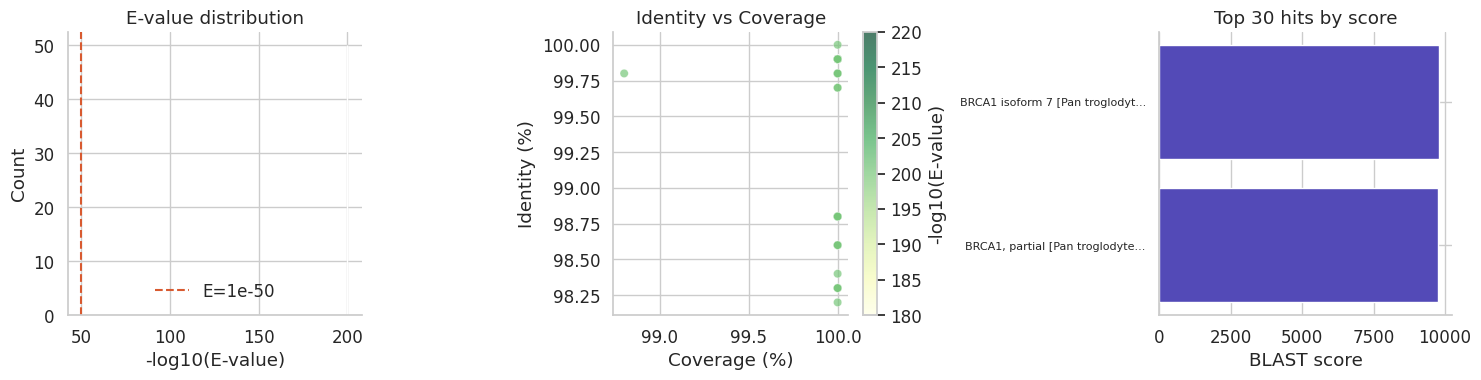

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


sns.set_theme(style="whitegrid", font_scale=1.1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))


# 1  Distribuzione E-value (scala logaritmica)
log_evalues = [-np.log10(e) if e > 0 else 200 for e in df["e_value"]]
axes[0].hist(log_evalues, bins=30, color="#1D9E75", edgecolor="white")
axes[0].set_xlabel("-log10(E-value)")
axes[0].set_ylabel("Count")
axes[0].set_title("E-value distribution")
axes[0].axvline(50, color="#D85A30", linestyle="--", linewidth=1.5, label="E=1e-50")
axes[0].legend(frameon=False)


# 2 Identity vs Coverage Scatter plot

scatter = axes[1].scatter(
    df["coverage_pct"],
    df["identity_pct"],
    c=log_evalues,
    cmap="YlGn",
    alpha=0.7,
    edgecolors="white",
    linewidth=0.3
)
plt.colorbar(scatter, ax=axes[1], label="-log10(E-value)")
axes[1].set_xlabel("Coverage (%)")
axes[1].set_ylabel("Identity (%)")
axes[1].set_title("Identity vs Coverage")


# 3 Top 30 hit — score bar chart
top30 = df[(~df['description'].str.contains("Homo"))&(~df['description'].str.contains("cancer"))].nlargest(30, "score").sort_values("score")
short_desc = top30["description"].str[:30] + "..."
axes[2].barh(range(len(top30)), top30["score"], color="#534AB7", edgecolor="white")
axes[2].set_yticks(range(len(top30)))
axes[2].set_yticklabels(short_desc, fontsize=8)
axes[2].set_xlabel("BLAST score")
axes[2].set_title("Top 30 hits by score")

sns.despine()
plt.tight_layout()
plt.savefig("brca_blast_plots.png", dpi=150, bbox_inches="tight")
plt.show()

## Esercizi

## Esercizio 1 Filtraggio avanzato
Filtra le hits che hanno identità > 90% e coverage > 80%. Quante ne rimangono ?

<details>
<summary>Show solution</summary>


```python

res=df[(df["identity_pct"]>90)&(df["coverage_pct"]>80)]

print(f"Trovati {res.shape[0]} hits")

```
</details>


## Esercizio 2 Confronto blastn vs blastp

Riesegui blastn e blastn sulla stessa sequenza e confronta gli E-value



## Esercizio 3 Query multipla con rate limiting

Fai blastp su 3 proteine diverse in loop, con time.sleep(10) tra una query e l'altra per rispettare i limiti NCBI, salvando ogni risultato XML con un nome diverso